# Testing the draft mosaic plot (`team/new_graphics/mosaic.py`)

This notebook exercises `make_mosaic()`, the draft implementation of a new
mosaic plot type. It is **not** wired into `.plot()` yet — this is for
visually checking the draft before integration.

A mosaic plot is for two discrete-ish variables — the same configuration
`tile` targets — but it encodes information differently:

- **Column widths** are proportional to each `x` category's marginal
  frequency.
- **Segment heights within a column** are proportional to that column's
  *conditional* frequency of each `y` category.
- Every rectangle's **area** is therefore proportional to the joint
  frequency of that `(x, y)` pair.

Where `tile` uses a sequential colormap (viridis) to encode a *magnitude*,
a mosaic plot uses the categorical palette (Okabe-Ito) to encode *which `y`
category* a segment is — one color per `y` value, consistent across every
column, with a legend. This makes it easy to see at a glance whether `y`'s
distribution changes across `x` (an association) or stays the same shape in
every column (independence) — the mosaic plot's main diagnostic use.

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All.

**What to look for in every plot:**
- Column widths proportional to each `x` value's marginal frequency
- Segments within a column colored by `y` category (Okabe-Ito), consistent
  across columns, with a legend outside the right edge of the axes
- Small gaps separate columns and the segments within each column
- Cell labels (percentage or count) appear only in cells large enough to
  hold them legibly
- Y-axis hidden (no shared numeric meaning across columns); x-axis labeled
  with the `x` categories; title reads "Mosaic Plot"


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/.
REPO_ROOT = Path.cwd().parents[2]

# Make `import symbulate` find the dev copy in this repo (not an older
# installed copy in site-packages), and `from mosaic import ...` find
# the draft module one folder up.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(Path.cwd().parent))

# The draft helper and its overlay-warning text
from mosaic import make_mosaic, MOSAIC_OVERLAY_WARNING

# Apply the global style file (Okabe-Ito palette, fonts, spines).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)


## 1. Two discrete numeric variables, unequal category sizes

`x` takes values 1-4 with unequal probabilities (0.5, 0.3, 0.15, 0.05); `y`
is `Poisson(2)`. The column widths should clearly differ, tracking `x`'s
marginal probabilities — this is the easiest way to confirm the width
geometry is correct before looking at anything more subtle.

`Poisson(2)` also produces more than 7 distinct values in a 4000-point
simulation, more than the 7 hues in the Okabe-Ito palette — so this doubles
as the test case for color reuse: categories past the 7th repeat an earlier
color *plus* a hatch pattern (so, e.g., category 7 is sky-blue-with-hatching,
not indistinguishable from category 0's plain sky-blue), and a `UserWarning`
explains why.

C:\Users\agw07\AppData\Local\Temp\ipykernel_11560\356803496.py:5: UserWarning: This mosaic plot has 10 distinct y-values, more than the 7 colors in the categorical palette, so some categories repeat a color (distinguished with a hatch pattern instead). A mosaic plot is hard to read with this many categories -- consider a plot type that doesn't rely on category color, like a tile plot.
  make_mosaic(x, y, ax, x_label="X", y_label="Y")


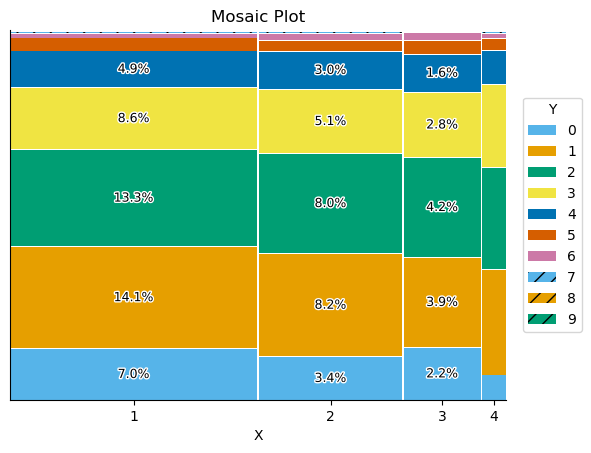

In [2]:
x = rng.choice([1, 2, 3, 4], size=4000, p=[0.5, 0.3, 0.15, 0.05])
y = rng.poisson(2, 4000)

ax = plt.gca()
make_mosaic(x, y, ax, x_label="X", y_label="Y")
plt.show()  # column 1 widest (p=0.5), column 4 narrowest (p=0.05)


## 2. Independence vs. association — the core diagnostic use

The whole point of a mosaic plot: if `x` and `y` are independent, every
column's segments should have (roughly) the same relative heights, since
`y`'s conditional distribution doesn't depend on `x`. If they're associated,
the segment heights visibly change from column to column.

### 2a. Independent — `Outcome` doesn't depend on `Group`

Segment heights should look about the same in every column.

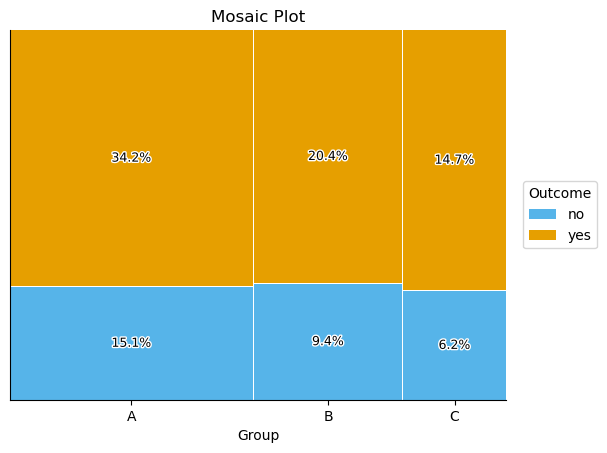

In [3]:
group_indep = rng.choice(["A", "B", "C"], size=4000, p=[0.5, 0.3, 0.2])
outcome_indep = rng.choice(["yes", "no"], size=4000, p=[0.7, 0.3])

ax = plt.gca()
make_mosaic(group_indep, outcome_indep, ax, x_label="Group", y_label="Outcome")
plt.show()  # every column: ~70% yes / ~30% no


### 2b. Associated — `Outcome` depends heavily on `Group`

`P(yes)` is 0.85 for Group A, 0.5 for Group B, and 0.15 for Group C. The
segment heights should visibly flip from mostly-yes on the left to
mostly-no on the right.

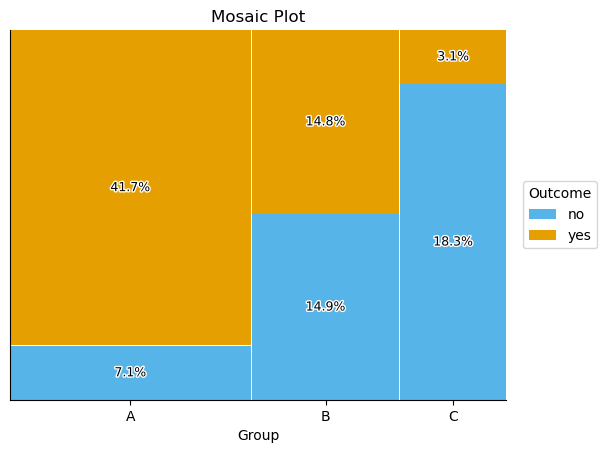

In [4]:
group = rng.choice(["A", "B", "C"], size=4000, p=[0.5, 0.3, 0.2])
p_yes = np.select([group == "A", group == "B", group == "C"], [0.85, 0.5, 0.15])
outcome = np.where(rng.uniform(size=4000) < p_yes, "yes", "no")

ax = plt.gca()
make_mosaic(group, outcome, ax, x_label="Group", y_label="Outcome")
plt.show()  # Group A mostly yes, Group C mostly no


## 3. Cell labels — `normalize=True` (default) vs. `normalize=False`

Using the associated Group/Outcome data from Section 2b: by default, each
cell shows its joint relative frequency as a percentage. `normalize=False`
switches the same labels to raw simulation counts instead. Either way, the
geometry (column widths, segment heights) is unchanged — `normalize` only
affects the label text.

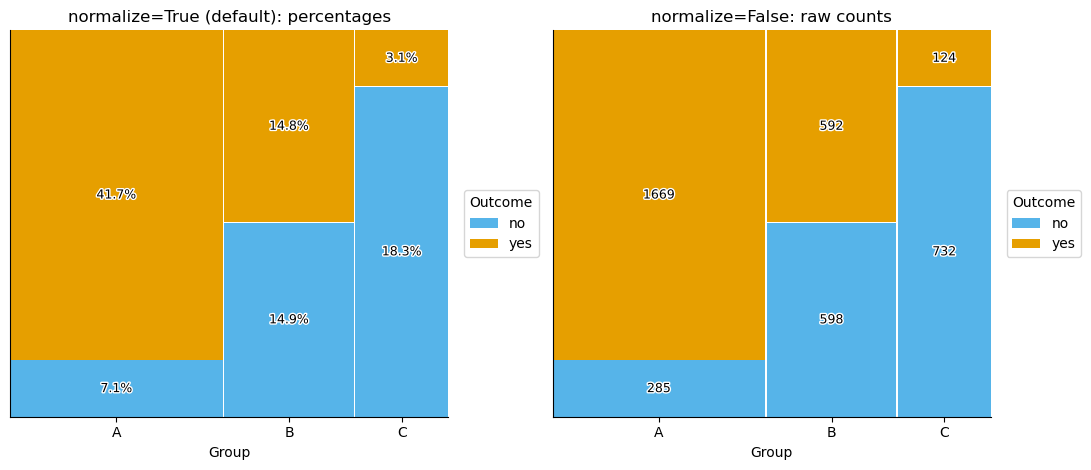

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

make_mosaic(group, outcome, axes[0], x_label="Group", y_label="Outcome")
axes[0].set_title("normalize=True (default): percentages")

make_mosaic(group, outcome, axes[1], normalize=False, x_label="Group", y_label="Outcome")
axes[1].set_title("normalize=False: raw counts")

plt.tight_layout()
plt.show()


## 4. Overlay behavior — the readability *warning* category

Per the overlay policy, a mosaic plot fills the whole axes, so overlaying a
second one is one of the designated **warning** cases (the same category as
`tile` and `hist2d`): the second mosaic still draws — covering the first —
and prints a warning, rather than erroring.

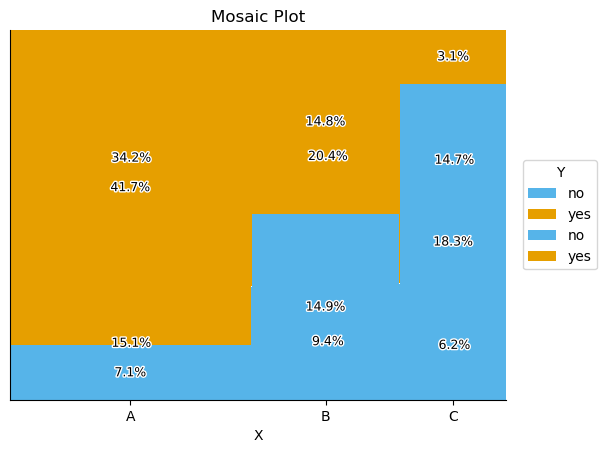

In [6]:
ax = plt.gca()
make_mosaic(group_indep, outcome_indep, ax)
make_mosaic(group, outcome, ax)  # draws, and prints the warning
plt.show()


## 5. With real symbulate simulation data

The same plot, but the data comes from an actual `RV(...).sim(...)` call
instead of raw numpy: two dependent categorical-ish variables built from a
`BoxModel`, the discrete × discrete case the lookup table could route to a
mosaic plot as a `tile` alternative.

Caveat while testing today: creating `RVResults` currently calls
`init_color()`, which resets the color cycle to tab10, and importing
`symbulate` switches the matplotlib style back to the old stylesheet (both
Phase 2 items) — so we re-apply the style *after* importing and simulating.

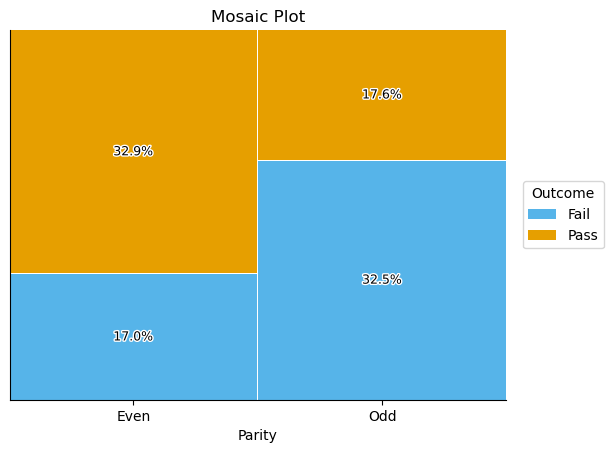

In [7]:
from symbulate import RV, BoxModel

# A biased two-stage draw: the die roll's parity (Odd/Even) is genuinely
# informative about a simulated pass/fail outcome, giving a real association
# to read off the mosaic -- not just independent noise.
die = RV(BoxModel([1, 2, 3, 4, 5, 6]))
parity = die.apply(lambda v: "Odd" if v % 2 else "Even")
outcome_rv = die.apply(lambda v: "Pass" if (v >= 4) else "Fail")
sims = (parity & outcome_rv).sim(4000)

plt.style.use(STYLE_PATH)  # re-apply: import + RVResults reset the style

arr = np.asarray(sims.results)
ax = plt.gca()
make_mosaic(arr[:, 0], arr[:, 1], ax, x_label="Parity", y_label="Outcome")
plt.show()


## Verification checklist

- [ ] Section 1: column widths visibly track `x`'s marginal probabilities (widest to narrowest: 1, 2, 3, 4)
- [ ] Section 1: segments within each column colored by `y` value (Okabe-Ito), consistent across columns; legend on the right lists all 10 values (colors repeat past 7)
- [ ] Section 1: labels only appear in cells tall and wide enough to hold them
- [ ] Section 1: categories past the 7th (hue-cycle repeats) show a hatch pattern in both the plot and the legend swatch, and a `UserWarning` explains why
- [ ] Section 2a (independent): segment heights look the same (~70/30) in every column
- [ ] Section 2b (associated): segment heights clearly differ across columns (mostly-yes on the left, mostly-no on the right)
- [ ] Section 3: default labels are percentages; `normalize=False` switches them to whole-number counts; geometry identical between the two
- [ ] Section 4: single mosaic plot prints no warning
- [ ] Section 4: second mosaic plot on the same axes draws AND prints the readability warning
- [ ] Section 5: works on real `.sim()` output, not just numpy arrays
- [ ] Every plot: x-axis labeled with the `x` categories; y-axis hidden; title "Mosaic Plot"; legend titled with `y_label`, placed outside the axes
